# Проект: Исследование стартапов

- Автор: Закатов Ю.Н.

## Введение <a id='introduction'></a>

Финансовая компания, предоставляющая льготные займы стартапам, хочет войти на инвестиционный рынок. Для разработки модели бизнеса, будет проведено исследование на исторических данных и получена информация, чтобы выработать понимание, какие данные могут быть полезны.

### Цель и задачи проекта

**Цель проекта:**  
Анализ исторических данных для разработки бизнес-модели инвестирования в стартапы, включая покупку, развитие и перепродажу.
<br />

**Задачи проекта:**  
1. Знакомство с данными: загрузка и первичная предобработка:<br />
   1.1 Вывод общей информации, исправление названия столбцов;<br />
   1.2 Смена типов и анализ пропусков.<br />
2. Предобработка данных, предварительное исследование:<br />
   2.1 Изучить раунды финансирования по годам;<br />
   2.2 Понять, зависит ли полнота сведений о сотрудниках от размера компаний;<br />
   2.3 Возможно ли объединение данных разных датасетов;<br />
   2.4 Привести данные к корректному виду датасета "company_and_rounds.csv".<br />
3. Исследовательский анализ объединённых таблиц:<br />
   3.1 Объединение данных;<br />
   3.2 Анализ выбросов;<br />
   3.3 Исследовать компании, которые были проданы за ноль или за один доллар<br />
   3.4 Исследовать цены стартапов по категориям;<br />
   3.5 Сколько раундов продержится стартап перед покупкой.<br />
4. Сделать итоговый вывод и рекомендации. <br /> 

### Описание данных

Датасеты, которые используются в проекте:

`company_and_rounds.csv`  
`acquisition.csv`  
`people.csv`  
`education.csv`  
`degrees.csv`  

---

Датасет `acquisition`, содержащий информацию о покупках одними компаниями других компаний:  
- **id** — идентификатор покупки.  
- **acquiring_company_id** — идентификатор покупающей компании.  
- **acquired_company_id** — идентификатор покупаемой компании.  
- **term_code** — варианты расчёта.  
- **price_amount** — сумма сделки.  
- **acquired_at** — дата сделки.

---

Датасет `company_and_rounds`, содержащий данные о компаниях и их финансировании:  
- **company ID** — идентификатор компании  
- **name** — название  
- **category code** — сфера деятельности  
- **status** — текущий статус (активна/закрыта)  
- **founded at** — дата основания  
- **closed at** — дата закрытия  
- **domain** — сайт компании  
- **network username** — ник в соцсетях  
- **country code** — код страны  
- **investment rounds** — количество инвестиционных раундов  
- **funding rounds** — количество раундов финансирования  
- **funding total** — общая сумма финансирования  
- **milestones** — ключевые этапы финансирования  
- **funding round id** — идентификатор раунда  
- **company id** — идентификатор компании  
- **funded at** — дата финансирования  
- **funding round type** — тип раунда (Seed, Series A и т.д.)  
- **raised amount** — привлечённая сумма  
- **pre money valuation** — оценка компании до инвестиций  
- **participants** — количество инвесторов  
- **is first round** — флаг первого раунда  
- **is last round** — флаг последнего раунда  

---

Датасет `education`, содержащий данные об образовании сотрудников:  
- **id** — идентификатор записи  
- **person_id** — идентификатор сотрудника  
- **instituition** — учебное заведение  
- **graduated_at** — дата окончания  

---

Датасет `people`, содержащий информацию о сотрудниках:  
- **id** — идентификатор  
- **first_name** — имя  
- **last_name** — фамилия  
- **company_id** — идентификатор компании  
- **network_username** — ник в соцсетях  

---

Датасет `degrees`, содержащий данные о степени образования:  
- **id** — идентификатор записи  
- **object_id** — идентификатор сотрудника  
- **degree_type** — уровень образования (бакалавр, магистр и т.д.)  
- **subject** — специальность 

### Содержимое проекта

1. [Введение](#introduction)<br />
2. [Знакомство с данными: загрузка и первичная предобработка](#loading_data)<br />
3. [Предобработка данных, предварительное исследование](#data_preprocessing)<br />
4. [Исследовательский анализ объединённых таблиц](#data_analysis)<br />
5. [Сделать итоговый вывод и рекомендации](#final_conclusion) <br /> 


## Знакомство с данными: загрузка и первичная предобработка <a id='loading_data'></a>


In [1]:
# убеждаемся, что на рабочем компьютере есть все необходимые библиотеки, если какая-то будет отсутствовать, она установится по этой команде
!pip install phik -U

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# pip install numpy==1.23.5

In [3]:
# импортируем необходимые библиотеки
import pandas as pd # импорт pandas
import matplotlib.pyplot as plt # импорт matplotlib
import seaborn as sns # импорт seaborn

In [4]:
#настройка отображения датафреймов
pd.set_option('display.float_format', '{:.3f}'.format) # округление float до 3 знаков после запятой

In [5]:
# загружаем данные датасетов
try:
    # смотрим есть ли локальный файл
    df_company_and_rounds = pd.read_csv("company_and_rounds.csv", sep=',', skiprows=0, on_bad_lines='error')
    df_acquisition = pd.read_csv("acquisition.csv", sep=',', skiprows=0, on_bad_lines='error')
    df_people = pd.read_csv("people.csv", sep=',', skiprows=0, on_bad_lines='error')
    df_education = pd.read_csv("education.csv", sep=',', skiprows=0, on_bad_lines='error')
    df_degrees = pd.read_csv("degrees.csv", sep=',', skiprows=0, on_bad_lines='error')
except:
    # если же его нет:
    df_company_and_rounds = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
    df_acquisition = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
    df_people = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')
    df_education = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
    df_degrees = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')


### Вывод общей информации, исправление названия столбцов

Познакомимся с данными. Для каждого датафрейма применим метод .info(). Посмотрим на количество пропусков, названия столбцов и типы данных.  
Поскольку датафреймов у нас 5, сделаем это через цикл.

In [6]:
dataframes = [df_company_and_rounds, df_acquisition, df_people, df_education, df_degrees]
names = ['df_company_and_rounds', 'acquisition', 'people', 'education', 'degrees']
for df, name in zip(dataframes, names):
    print(f"\n=== Информация датафрейма {name} ===\n")
    display(df.info())


=== Информация датафрейма df_company_and_rounds ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217471 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-nu

None


=== Информация датафрейма acquisition ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


None


=== Информация датафрейма people ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226700 non-null  object 
 2   last_name         226705 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


None


=== Информация датафрейма education ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


None


=== Информация датафрейма degrees ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98389 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


None

Так же для всех датафреймов применим метод .head() для вывода первых сток таблиц

In [7]:
dataframes = [df_company_and_rounds, df_acquisition, df_people, df_education, df_degrees]
names = ['df_company_and_rounds', 'acquisition', 'people', 'education', 'degrees']

for df, name in zip(dataframes, names):
    print(f"\n=== Датафрейм {name} ===")
    display(df.head())


=== Датафрейм df_company_and_rounds ===


,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.000,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.000,...,5.000,888.000,1.000,2005-10-01,series-a,5250000.000,0.000,2.000,0.000,1.000
1,1.000,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.000,...,5.000,889.000,1.000,2007-01-01,series-b,9500000.000,0.000,3.000,0.000,0.000
2,1.000,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.000,...,5.000,2312.000,1.000,2008-05-19,series-c+,25000000.000,0.000,4.000,1.000,0.000
3,10.000,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.000,...,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.000,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.000,...,4.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== Датафрейм acquisition ===


,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01



=== Датафрейм people ===


,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.000,NaN
1,100,Peter,Lester,27.000,NaN
2,1000,Dr. Steven,E. Saunders,292.000,NaN
3,10000,Neil,Capel,2526.000,NaN
4,100000,Sue,Pilsch,NaN,NaN



=== Датафрейм education ===


,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN



=== Датафрейм degrees ===


,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


Посмотрим на столбцы 'company  ID' и 'company  id' более внимательно. Выведем все строки датафрейма, где значения этих столбцов совпадают.

In [8]:
matches = df_company_and_rounds[df_company_and_rounds['company  ID'] == df_company_and_rounds['company  id']]
display(matches)

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.000,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.000,...,5.000,888.000,1.000,2005-10-01,series-a,5250000.000,0.000,2.000,0.000,1.000
1,1.000,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.000,...,5.000,889.000,1.000,2007-01-01,series-b,9500000.000,0.000,3.000,0.000,0.000
2,1.000,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.000,...,5.000,2312.000,1.000,2008-05-19,series-c+,25000000.000,0.000,4.000,1.000,0.000
15,1001.000,FriendFeed,web,acquired,2007-10-01,NaN,friendfeed.com,friendfeed,USA,0.000,...,3.000,1644.000,1001.000,2008-02-26,series-a,5000000.000,0.000,3.000,1.000,1.000
20,10014.000,Mobclix,mobile,acquired,2008-03-01,NaN,mobclix.com,mobclix,USA,0.000,...,4.000,6682.000,10014.000,2008-09-01,angel,0.000,0.000,1.000,1.000,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217466,3429.000,Zend Technologies,software,operating,1999-01-01,NaN,zend.com,networkzend,USA,0.000,...,6.000,20896.000,3429.000,2011-01-10,venture,7000000.000,0.000,1.000,1.000,0.000
217467,7748.000,Flowgram,web,closed,2007-06-01,2008-06-11,flowgram.com,network,USA,0.000,...,3.000,2836.000,7748.000,2008-01-31,angel,1300000.000,0.000,8.000,1.000,1.000
217469,43233.000,Photonet,photo_video,acquired,2010-03-01,NaN,Photonet.com,Photonet,USA,0.000,...,3.000,12687.000,43233.000,2010-03-05,angel,500000.000,0.000,2.000,0.000,1.000
217470,43233.000,Photonet,photo_video,acquired,2010-03-01,NaN,Photonet.com,Photonet,USA,0.000,...,3.000,21259.000,43233.000,2011-02-02,series-a,7000000.000,0.000,5.000,0.000,0.000


In [9]:
# выводим строки датафрейма в которых значения в столбцах 'company  ID' и 'company  id' не равны, а так же значения 'company  id' не равны NaN
difference = df_company_and_rounds[(df_company_and_rounds['company  ID'] != df_company_and_rounds['company  id']) 
    & df_company_and_rounds['company  id'].notna()]
display(difference)

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
217472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,457.000,1267.000,2005-01-01,series-a,48000000.000,0.000,2.000,1.000,1.000
217473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,471.000,558.000,2007-01-01,angel,300000.000,0.000,1.000,1.000,1.000
217474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,575.000,746.000,2004-09-01,angel,0.000,0.000,0.000,1.000,1.000
217475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,577.000,748.000,2007-01-01,series-a,1500000.000,2250000.000,0.000,1.000,1.000
217476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,597.000,804.000,2007-06-01,series-a,6000000.000,0.000,2.000,1.000,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,56454.000,282847.000,2011-01-31,other,5500000.000,0.000,0.000,1.000,1.000
217770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,56542.000,55477.000,2011-01-13,venture,10633300.000,0.000,0.000,0.000,1.000
217771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,56543.000,55477.000,2012-05-31,venture,2125720.000,0.000,0.000,1.000,0.000
217772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,56928.000,283492.000,2013-12-03,venture,3602480.000,0.000,5.000,1.000,1.000


На текущем этапе, после знакомства с данными, есть смысл привести названия столбцов датафрейма `company_and_rounds` к формату "snake_case". Однако в этом датафрейме есть 2 столбца с почти одинаковым названием - "company  ID" и "company  id", при переводе символов к нужному нам формату эти столбцы будут иметь идентичные названия. Что бы этого избежать, дополнительно переименуем столбец "company  id" в "company  id dupl", т.к. при дополнительном анализе мы выяснили, что все значения (за исключением 302-х случаев) дублируются в обоих столбцах.   
Названия столбцов остальных датафреймов в норме.  

In [11]:
# переименуем столбец 'company  id' в 'company_id_dupl'
df_company_and_rounds.rename(columns={'company  id': 'company_id_dupl'}, inplace=True)

# приведем все символы названия столбцов к нижнему регистру и заменим двойные пробелы знаком нижнего подчеркивания
df_company_and_rounds.columns = [x.lower().replace('  ', '_') for x in df_company_and_rounds.columns.values]

In [12]:
# проверяем результат
df_company_and_rounds.columns

Index(['company_id', 'name', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'network_username', 'country_code',
       'investment_rounds', 'funding_rounds', 'funding_total', 'milestones',
       'funding_round_id', 'company_id_dupl', 'funded_at',
       'funding_round_type', 'raised_amount', 'pre_money_valuation',
       'participants', 'is_first_round', 'is_last_round'],
      dtype='object')

### 1.2. Смена типов и анализ пропусков


In [13]:
# приведем данные в столбцах датафрейма "df_company_and_rounds" с датами к нужному нам типу "datetime"
for column in ['founded_at', 'closed_at', 'funded_at']:
     df_company_and_rounds[column] = pd.to_datetime(df_company_and_rounds[column])

In [14]:
# проверяем результат
df_company_and_rounds.dtypes

company_id                    float64
name                           object
category_code                  object
status                         object
founded_at             datetime64[ns]
closed_at              datetime64[ns]
domain                         object
network_username               object
country_code                   object
investment_rounds             float64
funding_rounds                float64
funding_total                 float64
milestones                    float64
funding_round_id              float64
company_id_dupl               float64
funded_at              datetime64[ns]
funding_round_type             object
raised_amount                 float64
pre_money_valuation           float64
participants                  float64
is_first_round                float64
is_last_round                 float64
dtype: object

In [15]:
# проверяем результат отображения
df_company_and_rounds.sample(5)

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id_dupl,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
166937,41225.000,DBVu,analytics,operating,2010-01-25,NaT,dbvu.net,dbvu,NaN,0.000,...,1.000,11734.000,41225.000,2010-01-28,angel,121858.000,0.000,0.000,1.000,1.000
27546,162885.000,adingo,advertising,operating,2008-06-02,NaT,adingo.jp,adingo_pr,JPN,0.000,...,0.000,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
55624,192217.000,HUNT LASERCUT,other,operating,1992-01-01,NaT,lasercut.com.au,NaN,NaN,0.000,...,0.000,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
206467,76903.000,PlacePoint,mobile,operating,NaT,NaT,placepoint.in,placepointplus,NaN,0.000,...,0.000,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
129311,263933.000,"Mosec, Mobile Secretary",software,operating,NaT,NaT,NaN,NaN,NaN,0.000,...,0.000,48527.000,263933.000,2011-12-01,angel,50000.000,0.000,1.000,1.000,1.000


In [16]:
# приведем данные в столбце датафрейма "df_acquisition" с датой к нужному нам типу "datetime"
df_acquisition['acquired_at'] = pd.to_datetime(df_acquisition['acquired_at'])

In [17]:
# проверяем результат
df_acquisition.dtypes

id                               int64
acquiring_company_id             int64
acquired_company_id              int64
term_code                       object
price_amount                     int64
acquired_at             datetime64[ns]
dtype: object

In [18]:
# проверяем результат отображения
df_acquisition.sample(5)

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
2611,2963,1359,40952,NaN,225000000,2007-09-01
893,1090,22119,22116,cash,12000,2007-05-01
4295,4743,2680,64322,NaN,0,2007-03-01
7207,8022,5346,16070,NaN,0,2012-12-17
4084,4527,3246,63487,NaN,0,2007-02-14


In [19]:
# приведем данные в столбце датафрейма "education" с датой к нужному нам типу "datetime"
df_education['graduated_at'] = pd.to_datetime(df_education['graduated_at'])

In [20]:
# проверяем результат
df_education.dtypes

id                       int64
person_id                int64
instituition            object
graduated_at    datetime64[ns]
dtype: object

In [21]:
# проверяем результат отображения
df_education.sample(5)

,id,person_id,instituition,graduated_at
29873,29871,90502,Riverdale,1999-01-01
51893,51891,125243,Brigham Young University,1984-01-01
75401,75397,230152,Georgetown University,2010-01-01
94108,94107,250131,Exeter University,NaT
35910,35906,28819,Northwestern University,1982-01-01


Поменяли тип данных в столбцах датафреймов, которые хранят значения даты и времени. Теперь оценим полноту данных, выведем информацию по датафреймам на наличие пропусков в относительных и абсолютных значениях. 

In [22]:
dataframes = [df_company_and_rounds, df_acquisition, df_people, df_education, df_degrees]
names = ['df_company_and_rounds', 'acquisition', 'people', 'education', 'degrees']

for df, name in zip(dataframes, names):
    print(f"\n=== Датафрейм {name} ===")
    display(pd.DataFrame({
        'Процент пропусков (%)': round(df.isna().mean()*100, 2),
        'Количество пропусков': df.isna().sum()
    })
        .sort_values(by = 'Количество пропусков', ascending=False).style.background_gradient('Blues'))


=== Датафрейм df_company_and_rounds ===


,Процент пропусков (%),Количество пропусков
closed_at,98.420000,214325
funded_at,75.810000,165094
is_last_round,75.700000,164846
funding_round_type,75.700000,164846
is_first_round,75.700000,164846
participants,75.700000,164846
pre_money_valuation,75.700000,164846
raised_amount,75.700000,164846
funding_round_id,75.700000,164846
company_id_dupl,75.700000,164846



=== Датафрейм acquisition ===


,Процент пропусков (%),Количество пропусков
term_code,80.540000,7576
acquired_at,0.310000,29
id,0.000000,0
acquiring_company_id,0.000000,0
acquired_company_id,0.000000,0
price_amount,0.000000,0



=== Датафрейм people ===


,Процент пропусков (%),Количество пропусков
company_id,84.730000,192094
network_username,82.860000,187842
first_name,0.000000,9
last_name,0.000000,4
id,0.000000,0



=== Датафрейм education ===


,Процент пропусков (%),Количество пропусков
graduated_at,47.040000,51556
instituition,0.050000,55
id,0.000000,0
person_id,0.000000,0



=== Датафрейм degrees ===


,Процент пропусков (%),Количество пропусков
subject,25.830000,28312
degree_type,10.240000,11221
id,0.000000,0
object_id,0.000000,0


#### Промежуточный вывод после знакомства с данными

После первичного знакомства с данными:
- привели названия столбцов датафрейма `company_and_rounds` к формату "snake_case", так же переименовали столбец "company id" в "company_id_dupl";
- поменяли тип данных (которые хранят значения даты и времени) для столбцов датафреймов `company_and_rounds`, `acquisition` и `education` c "object" на "datetime64[ns]";
- оценили полноту данных, вывели количество пропусков в датасетах.
   
Количество пропусков довольно большое, особенно в датасете `company_and_rounds`, однако на данном этапе не понятно как можно обработать эти пропуски. Удаление строк с пропусками приведет к большой потере данных, так же у нас нет столбцов на основе которых мы можем эти пропуски заполнить. Учитывая размер датасета `company_and_rounds` даже с учетом пропусков, у нас остается довольно большая выборка, так что пока будем работать с тем что есть. 

## Предобработка данных, предварительное исследование


### 2.1. Раунды финансирования по годам


In [23]:
# Создаем столбец с годом из даты финансирования
df_company_and_rounds['year'] = df_company_and_rounds['funded_at'].dt.year

# Создаем сводную таблицу с помощью pivot_table
pivot_summary = pd.pivot_table(
    data=df_company_and_rounds,
    index='year',
    values='raised_amount',
    aggfunc={
        'raised_amount': ['count', 'median']  # Медиана и количество раундов
    }
)

# Переименовываем столбцы для удобства
pivot_summary.columns = ['total_rounds', 'typical_round_size']

# Фильтруем года с более чем 50 раундами
pivot_summary = pivot_summary[pivot_summary['total_rounds'] > 50]

# Сортируем по году
pivot_summary = pivot_summary.sort_index()

# Отображаем результат
display(pivot_summary.style
        .set_caption("Сводная статистика по раундам финансирования по годам")
        .background_gradient(subset=['typical_round_size'], cmap='Blues'))

,total_rounds,typical_round_size
year,,
1999.000000,76,2000000.000000
2000.000000,125,4200000.000000
2001.000000,96,3000000.000000
2002.000000,116,4200000.000000
2003.000000,159,3000000.000000
2004.000000,291,5000000.000000
2005.000000,1633,5500000.000000
2006.000000,2436,5000000.000000
2007.000000,3279,3973320.000000


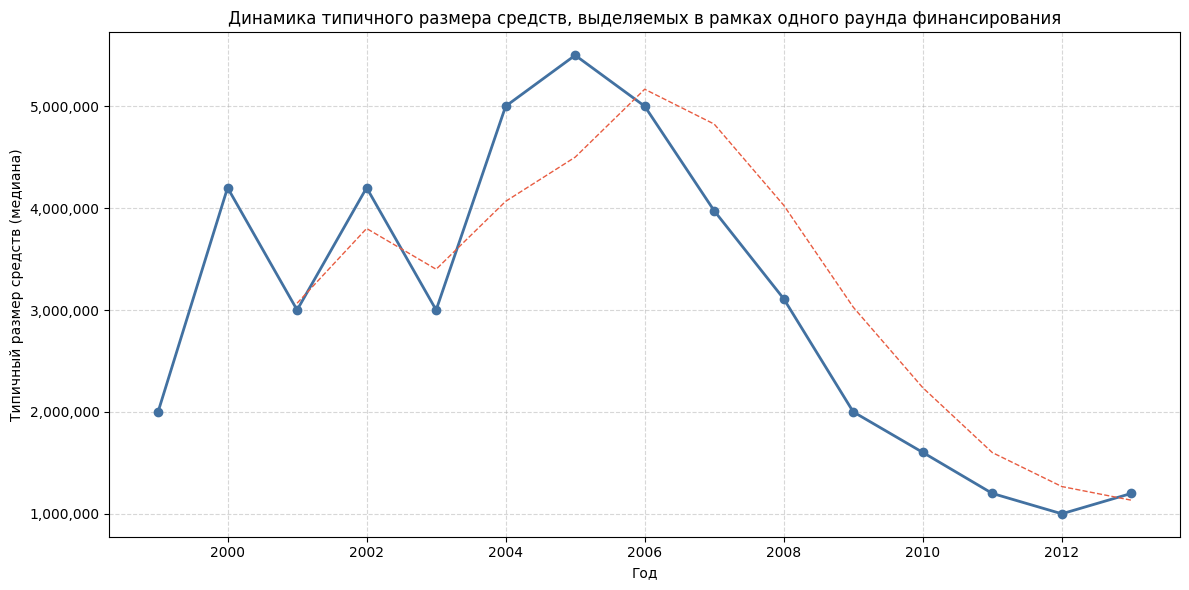

In [24]:
ax = pivot_summary['typical_round_size'].plot(
    kind='line',
    figsize=(12, 6),
    marker='o',
    markersize=6,
    linewidth=2,
    color='#4271a1',
    title='Динамика типичного размера средств, выделяемых в рамках одного раунда финансирования'
)

# Добавляем скользящую среднюю (окно 3 периода)
window_size = 3
rolling_mean = pivot_summary['typical_round_size'].rolling(window=window_size).mean()
rolling_mean.plot(ax=ax, color='#e85c41', linewidth=1, linestyle='--')

# Настройка оформления
ax.set_xlabel('Год')
ax.set_ylabel('Типичный размер средств (медиана)')
ax.yaxis.set_major_formatter('{x:,.0f}')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [25]:
# Создаем столбец с годом из даты финансирования
df_company_and_rounds['year'] = df_company_and_rounds['funded_at'].dt.year
df_company_and_rounds['month'] = df_company_and_rounds['funded_at'].dt.month

# Создаем сводную таблицу с помощью pivot_table
pivot_summary_2013 = pd.pivot_table(
    data=df_company_and_rounds,
    index=['year', 'month'],
    values='raised_amount',
    aggfunc={
        'raised_amount': ['count', 'median']  # Медиана и количество раундов
    }
)

# Переименовываем столбцы для удобства
pivot_summary_2013.columns = ['total_rounds', 'typical_round_size']

# Фильтруем годы с более чем 50 раундами
pivot_summary_2013 = pivot_summary_2013[(pivot_summary_2013['typical_round_size'] > 50) & (pivot_summary_2013.index.get_level_values('year') == 2013)]

# Сортируем по году
pivot_summary_2013 = pivot_summary_2013.sort_index()

# Отображаем результат
display(pivot_summary_2013.style
        .set_caption("Сводная статистика по раундам финансирования по годам")
        .background_gradient(subset=['typical_round_size'], cmap='Blues'))

На основе полученных данных, можно сказать следующее:
- 2005 год является лидером по типичному размеру собранных в рамках одного раунда средств (5 500 000.0 ус.ед. и 1633 раундов финансирования);
- в целом, период с 2004 по 2006 годы включительно, был самым щедрым по величине стредств выделяемых в рамках одного раунда финансирования;
- после 2005 года наблюдается нисходящая тенденция по величине стредств выделяемых в рамках одного раунда финансирования, однако количество раундов финансирования наоборот растет.

Если рассматривать отдельно 2013 год, то можно сказать об увеличении размера средств выделяемых в рамках одного раунда финансирования к концу года, по количеству раундов финансирования заметной тенденции не наблюдается.


### 2.2. Люди и их образование


In [26]:
# объединяем датафреймы в один
df_people_education = pd.merge(df_people, df_education, left_on='id', right_on='person_id', how='outer')

In [27]:
# смотрим результат
df_people_education.sample(20)

,id_x,first_name,last_name,company_id,network_username,id_y,person_id,instituition,graduated_at
3612,3455.000,Bill,Harris,1331.000,NaN,103170.000,3455.000,Harvard College,NaT
122258,128212.000,Kip,Baumschein,NaN,NaN,NaN,NaN,NaN,NaT
114065,117782.000,Andrew,Davis,142940.000,cop_epaste,17328.000,117782.000,Adschool,2007-01-01
4277,4115.000,Roy,Solomon,1095.000,NaN,NaN,NaN,NaN,NaT
239498,243341.000,Eric,Fisher,NaN,NaN,88414.000,243341.000,University of Texas School,NaT
15825,15182.000,Loc,Ngo,NaN,NaN,NaN,NaN,NaN,NaT
61335,58788.000,Stephen,Cunningham,NaN,NaN,NaN,NaN,NaN,NaT
159531,172925.000,Margit,Zwemer,47056.000,MPZwemer,90502.000,172925.000,Stanford University,NaT
71039,68428.000,Ammar,Ibrahim,NaN,NaN,NaN,NaN,NaN,NaT
268039,268410.000,Albert,Alemany,NaN,alemany,109457.000,268410.000,Universitat Oberta de Catalunya,NaT


In [28]:
# создадим новый столбец 'company_size' с количеством сотрудников в каждой компании
df_people_education['company_size'] = df_people_education.groupby('company_id')['id_x'].transform('count')
df_people_education.head(20)

,id_x,first_name,last_name,company_id,network_username,id_y,person_id,instituition,graduated_at,company_size
0,2.000,Ben,Elowitz,4993.000,elowitz,699.000,2.000,"University of California, Berkeley",1994-01-01,2.000
1,2.000,Ben,Elowitz,4993.000,elowitz,700.000,2.000,"University of California, Berkeley",1994-01-01,2.000
2,3.000,Kevin,Flaherty,1.000,NaN,706.000,3.000,Washington University in St Louis,NaT,3.000
3,3.000,Kevin,Flaherty,1.000,NaN,707.000,3.000,Indiana University,NaT,3.000
4,4.000,Raju,Vegesna,3.000,NaN,NaN,NaN,NaN,NaT,5.000
5,5.000,Ian,Wenig,3.000,NaN,47870.000,5.000,The Aji Network,2005-01-01,5.000
6,5.000,Ian,Wenig,3.000,NaN,47871.000,5.000,McGill University,1986-01-01,5.000
7,6.000,Kevin,Rose,16441.000,kevinrose,15624.000,6.000,"University of Nevada, Las Vegas",NaT,6.000
8,6.000,Kevin,Rose,16441.000,kevinrose,69509.000,6.000,Montessori,1983-01-01,6.000
9,7.000,Jay,Adelson,4.000,jayadelson,22649.000,7.000,Boston University,1992-01-01,18.000


In [29]:
# проверим данные, сгруппируем данные по компании и выведем количество сотрудников для каждой из них
df_people_education_groupby = df_people_education.groupby('company_id').agg({'id_x': 'nunique'}).reset_index() # считаем только уникальные значения столбца
df_people_education_groupby = df_people_education_groupby.rename(columns={'id_x': 'employee_count'})
display(df_people_education_groupby)

,company_id,employee_count
0,1.000,2
1,2.000,1
2,3.000,3
3,4.000,13
4,5.000,61
...,...,...
22917,285897.000,2
22918,285953.000,1
22919,285972.000,2
22920,285996.000,1


Посмотрим на распределение значений количества работников в компании для решения вопроса категоризации

In [30]:
df_1 = df_people_education_groupby.groupby('employee_count').agg({'company_id': 'count'}).reset_index()
df_1['percent'] = (df_1['company_id'] / df_1['company_id'].sum() * 100).round(2)
display(df_1)

,employee_count,company_id,percent
0,1,18117,79.040
1,2,2709,11.820
2,3,921,4.020
3,4,450,1.960
4,5,237,1.030
5,6,138,0.600
6,7,100,0.440
7,8,59,0.260
8,9,46,0.200
9,10,25,0.110


Как видим, большинство значений (79.04%) принадлежит компаниям с 1 сотрудником. Далее идет 11.82% значений у компаний с 2-мя сотрудниками. У компаний с 3-мя сотрудниками - 4.02%. Разброс значений довольно большой и сильно смещен в сторону компаний с 1-м сотрудником, поэтому для более детального рассмотрения вопроса категоризации, желательно выделить более узкие рамки в категориях компаний.  
Категоризировать будем по следующим значениям, что бы получить более детальную информацию по компаниям:  
- 1 сотрудник (79.04% компаний);
- 2 сотрудника (11.82% компаний);
- 3 сотрудника (4.02% компаний);
- 4-5 сотрудников (2.99% компаний);
- 6-10 сотрудников (1.61% компаний);
- 11-25 сотрудников (0.42% компаний)
- 26 и более сотрудников (0.1% компаний). 

In [31]:
bins = [0, 1, 2, 3, 5, 10, 25, float('inf')]
labels = ['1 employee', '2 employes', '3 employes', '4-5 employes', '6-10 employes', '11-25 employes', '26+ employes']

df_people_education['size_group_category'] = pd.cut(df_people_education['company_size'], bins=bins, labels=labels)
# проверяем результат
df_people_education.head(20)

,id_x,first_name,last_name,company_id,network_username,id_y,person_id,instituition,graduated_at,company_size,size_group_category
0,2.000,Ben,Elowitz,4993.000,elowitz,699.000,2.000,"University of California, Berkeley",1994-01-01,2.000,2 employes
1,2.000,Ben,Elowitz,4993.000,elowitz,700.000,2.000,"University of California, Berkeley",1994-01-01,2.000,2 employes
2,3.000,Kevin,Flaherty,1.000,NaN,706.000,3.000,Washington University in St Louis,NaT,3.000,3 employes
3,3.000,Kevin,Flaherty,1.000,NaN,707.000,3.000,Indiana University,NaT,3.000,3 employes
4,4.000,Raju,Vegesna,3.000,NaN,NaN,NaN,NaN,NaT,5.000,4-5 employes
5,5.000,Ian,Wenig,3.000,NaN,47870.000,5.000,The Aji Network,2005-01-01,5.000,4-5 employes
6,5.000,Ian,Wenig,3.000,NaN,47871.000,5.000,McGill University,1986-01-01,5.000,4-5 employes
7,6.000,Kevin,Rose,16441.000,kevinrose,15624.000,6.000,"University of Nevada, Las Vegas",NaT,6.000,6-10 employes
8,6.000,Kevin,Rose,16441.000,kevinrose,69509.000,6.000,Montessori,1983-01-01,6.000,6-10 employes
9,7.000,Jay,Adelson,4.000,jayadelson,22649.000,7.000,Boston University,1992-01-01,18.000,11-25 employes


В исходных данных у нас так же присутствует таблица `degrees.csv`, которая содержит информацию о типе образования сотрудников, при знакомстве с данными, мы выводили первые строки этой таблицы. Её возможно присоединить к нашему датасету, однако значения в поле "object_id" необходимо преобразовать (удалить префикс "p:" перед значениями идентификатора сотрудника)

In [32]:
# удаляем префикс 'p:' из значений поля object_id
df_degrees['object_id'] = df_degrees['object_id'].str.replace('p:', '', regex=False)

# выводим первые строки обновленного degrees_df
df_degrees.head()

,id,object_id,degree_type,subject
0,1,6117,MBA,NaN
1,2,6136,BA,"English, French"
2,3,6136,MS,Mass Communication
3,4,6005,MS,Internet Technology
4,5,5832,BCS,"Computer Science, Psychology"


In [33]:
# меняем тип данных столбца "object_id" на целочисленный
df_degrees['object_id'] = pd.to_numeric(df_degrees['object_id'], errors='coerce', downcast='integer')

In [34]:
df_degrees.sort_values('object_id').head(20)

,id,object_id,degree_type,subject
698,699,2,BS,Electrical Engineering/Computer Science
699,700,2,BS,Applied Mathematics
705,706,3,BBA,NaN
706,707,3,MBA,NaN
47870,47871,5,BS,"Biology, Psychology"
47869,47870,5,Degree,Advanced Business Professional Course
69508,69509,6,NaN,NaN
15623,15624,6,NaN,NaN
22648,22649,7,NaN,"Film and Broadcasting, Computer Science Concen..."
1026,1027,8,BS,Computer Science


Датафрейм `df_degrees` подготовили для объединения, объединять будем по идентификаторам записи об образовании, тип объединения выберем "left". 

In [35]:
# добавляем информацию из датафрейма "df_degrees" к объединенному датафрейму "df_people_education"
df_people_education_degrees = pd.merge(df_people_education, df_degrees, left_on='id_y', right_on='id', how='left')

In [36]:
# проверяем результат
df_people_education_degrees.head(10)

,id_x,first_name,last_name,company_id,network_username,id_y,person_id,instituition,graduated_at,company_size,size_group_category,id,object_id,degree_type,subject
0,2.000,Ben,Elowitz,4993.000,elowitz,699.000,2.000,"University of California, Berkeley",1994-01-01,2.000,2 employes,699.000,2.000,BS,Electrical Engineering/Computer Science
1,2.000,Ben,Elowitz,4993.000,elowitz,700.000,2.000,"University of California, Berkeley",1994-01-01,2.000,2 employes,700.000,2.000,BS,Applied Mathematics
2,3.000,Kevin,Flaherty,1.000,NaN,706.000,3.000,Washington University in St Louis,NaT,3.000,3 employes,706.000,3.000,BBA,NaN
3,3.000,Kevin,Flaherty,1.000,NaN,707.000,3.000,Indiana University,NaT,3.000,3 employes,707.000,3.000,MBA,NaN
4,4.000,Raju,Vegesna,3.000,NaN,NaN,NaN,NaN,NaT,5.000,4-5 employes,NaN,NaN,NaN,NaN
5,5.000,Ian,Wenig,3.000,NaN,47870.000,5.000,The Aji Network,2005-01-01,5.000,4-5 employes,47870.000,5.000,Degree,Advanced Business Professional Course
6,5.000,Ian,Wenig,3.000,NaN,47871.000,5.000,McGill University,1986-01-01,5.000,4-5 employes,47871.000,5.000,BS,"Biology, Psychology"
7,6.000,Kevin,Rose,16441.000,kevinrose,15624.000,6.000,"University of Nevada, Las Vegas",NaT,6.000,6-10 employes,15624.000,6.000,NaN,NaN
8,6.000,Kevin,Rose,16441.000,kevinrose,69509.000,6.000,Montessori,1983-01-01,6.000,6-10 employes,69509.000,6.000,NaN,NaN
9,7.000,Jay,Adelson,4.000,jayadelson,22649.000,7.000,Boston University,1992-01-01,18.000,11-25 employes,22649.000,7.000,NaN,"Film and Broadcasting, Computer Science Concen..."


In [37]:
# Создаем столбец not_education, который будет идентифицировать пропуски в столбце instituition (1-пропуск, 0-значение есть) 
df_people_education_degrees['not_education'] = (df_people_education_degrees['instituition'].isnull().astype(int))
df_people_education_degrees.head()

,id_x,first_name,last_name,company_id,network_username,id_y,person_id,instituition,graduated_at,company_size,size_group_category,id,object_id,degree_type,subject,not_education
0,2.000,Ben,Elowitz,4993.000,elowitz,699.000,2.000,"University of California, Berkeley",1994-01-01,2.000,2 employes,699.000,2.000,BS,Electrical Engineering/Computer Science,0
1,2.000,Ben,Elowitz,4993.000,elowitz,700.000,2.000,"University of California, Berkeley",1994-01-01,2.000,2 employes,700.000,2.000,BS,Applied Mathematics,0
2,3.000,Kevin,Flaherty,1.000,NaN,706.000,3.000,Washington University in St Louis,NaT,3.000,3 employes,706.000,3.000,BBA,NaN,0
3,3.000,Kevin,Flaherty,1.000,NaN,707.000,3.000,Indiana University,NaT,3.000,3 employes,707.000,3.000,MBA,NaN,0
4,4.000,Raju,Vegesna,3.000,NaN,NaN,NaN,NaN,NaT,5.000,4-5 employes,NaN,NaN,NaN,NaN,1


In [38]:
not_education_by_company_size = (df_people_education_degrees.groupby('size_group_category')['not_education'].mean())
display(not_education_by_company_size)

C:\Users\Юра\AppData\Local\Temp\ipykernel_5212\3867585178.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  not_education_by_company_size = (df_people_education_degrees.groupby('size_group_category')['not_education'].mean())


size_group_category
1 employee       0.593
2 employes       0.227
3 employes       0.228
4-5 employes     0.278
6-10 employes    0.316
11-25 employes   0.295
26+ employes     0.191
Name: not_education, dtype: float64

Как видим, самый большой процент сотрудников без информации об образовании наблюдается в компаниях с 1-м сотрудником - 59.3% (возможно это связано с гораздо большим количеством этих компаний по сравнению с другими). В компаниях с 2-мя и 3-мя сотрудниками одни из самых низких процентов - 22.7% и 22.8% соответсвтенно, самый низкий процент наблюдаетя в компаниях с 26+ сотрудниками - 19.1% (однако, учитывая, что в наших данных таких компаний 19 или всего 0.1% от общего количества, результат по этой категории может быть не точным).  

Таблица "degrees.csv" содержит расширенные сведения об образовании, но для наших расчетов не предоставляет дополнительных данных, поэтому её использование не обязательно.

### 2.3. Объединять или не объединять — вот в чём вопрос


In [39]:
# Список датафреймов и их названий
dataframes = {
    'df_acquisition': df_acquisition,
    'df_company_and_rounds': df_company_and_rounds,
    'df_degrees': df_degrees,
    'df_education': df_education,
    'df_people': df_people
}

In [40]:
# проверка уникальности значений
for df_name, df in dataframes.items():
    if 'network_username' in df.columns:
        unique_count = df['network_username'].nunique()
        total_count = df['network_username'].count()
        print(f"'{df_name}' - Unique values: {unique_count}, Total records: {total_count}")
    else:
        print(f"'{df_name}' does not have the column 'network_username'.")

'df_acquisition' does not have the column 'network_username'.
'df_company_and_rounds' - Unique values: 79571, Total records: 95534
'df_degrees' does not have the column 'network_username'.
'df_education' does not have the column 'network_username'.
'df_people' - Unique values: 38421, Total records: 38867


In [41]:
# проверка дублирующихся значений
for df_name, df in dataframes.items():
    if 'network_username' in df.columns:
        duplicate_count = df['network_username'].duplicated().sum()
        print(f"'{df_name}' has {duplicate_count} duplicate network_username values.")

'df_company_and_rounds' has 138202 duplicate network_username values.
'df_people' has 188287 duplicate network_username values.


In [42]:
# Проверка дублирования между датафреймами
# Соберем все значения network_username в один список
all_usernames = pd.concat([df['network_username'] for df in dataframes.values() if 'network_username' in df.columns])
unique_usernames = all_usernames.nunique()
duplicate_usernames = all_usernames[all_usernames.duplicated()].nunique()

print(f"Total unique network_usernames across all dataframes: {unique_usernames}")
print(f"Total duplicate network_usernames across all dataframes: {duplicate_usernames}")

Total unique network_usernames across all dataframes: 115793
Total duplicate network_usernames across all dataframes: 10799


---
После анализа возможности использования столбца `network_username` для объединения данных, скажем следующее:
- данный столбец присутствует только в двух датафреймах: `df_company_and_rounds` и `df_people`;
- в датасете `company_and_rounds_df`: *79571* уникальных значений из *95534* записей, с *138202* дублирующимися значениями;
- в датасете `people_df`: *38421* уникальных значений из *38867* записей, с *188287* дублирующимися значениями
- всего уникальных значений `network_username` во всех датафреймах: *115793*;
- всего дублирующихся значений `network_username`: *10799*.
<br />

Учитывая информацию, которую мы получили, можно сделать вывод, что столбцы с именем `network_username` не подходят для объединения данных, в виду большого количества дублирующихся значений. В результате объединения могут возникнуть ошибки, если одино и тот же значение в столбце `network_username` будет относиться к разным записям в разных датафреймах.

In [43]:
!pip install matplotlib-venn -q 
from matplotlib_venn import venn2

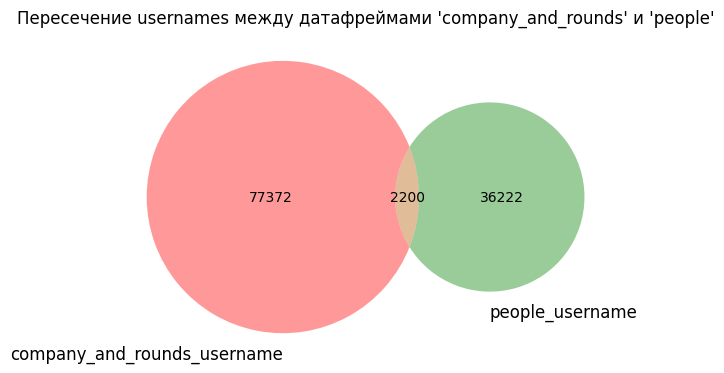

In [44]:
venn2([set(df_company_and_rounds['network_username']), set(df_people['network_username'])], 
      set_labels=('company_and_rounds_username', 'people_username'))
plt.title("Пересечение usernames между датафреймами 'company_and_rounds' и 'people'") 
plt.show()

При помощи диаграммы Венна мы наглядно видим, что объединение двух датафреймов `df_company_and_rounds` и `df_people` по столбцу `network_username` не является оптимальным решением.  
Например при способе объединения "inner" мы потеряем значительную часть информации из обоих таблиц, при способе объединения "left" получим много значений NaN.  
Из положительных моментов данного объединения наверное можно отметить только появление в таблице `df_company_and_rounds` информации о сотрудниках, что может помоч в некоторых вариантах агрегации данных. 


### 2.4. Проблемный датасет и причина возникновения пропусков

Для анализа датасета `company_and_rounds.csv` вспомним структуру и обратим внимание на пропуски. Для этого применим метод .info() и посчитаем процент пропусков в столбцах. 

In [45]:
df_company_and_rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id           217472 non-null  float64       
 1   name                 217471 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

In [46]:
display(pd.DataFrame({
    'Процент пропусков (%)': round(df_company_and_rounds.isna().mean()*100, 2),
    'Количество пропусков': df_company_and_rounds.isna().sum()
})
    .style.background_gradient('Blues'))

,Процент пропусков (%),Количество пропусков
company_id,0.140000,302
name,0.140000,303
category_code,33.930000,73888
status,0.140000,302
founded_at,49.510000,107818
closed_at,98.420000,214325
domain,32.430000,70615
network_username,56.130000,122240
country_code,50.130000,109167
investment_rounds,0.140000,302


После анализа общей информации и пропущенных значений, можно предположить, что данные по компаниям изначально хранились в двух таблицах:

- таблица компаний — с информацией о каждой компании (название, категория, статус, дата основания и т.д.);
- таблица раундов финансирования — с детальной информацией о каждом раунде финансирования (сумма, тип, дата и т.д.).
  
В текущем датасете `company_and_rounds.csv` эти две таблицы объединены, но из-за этого появились пропуски там, где компания не имеет информации о раундах.  
Для дальнейшего удобства работы, возможно разделить текущий датасет на два (информация о компаниях и информация о раундах финансирования). Назовем будующие датасеты - `df_companies` и `df_rounds` соответственно. 

In [47]:
# разделение данных на компании и раунды
# таблица компаний
companies_columns = [
    'company_id', 'name', 'category_code', 'status', 'founded_at', 'closed_at',
    'domain', 'network_username', 'country_code', 'investment_rounds',
    'funding_rounds', 'funding_total', 'milestones'
]

df_companies = df_company_and_rounds[companies_columns]

In [48]:
df_companies.head()

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.000,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.000,3.000,39750000.000,5.000
1,1.000,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.000,3.000,39750000.000,5.000
2,1.000,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.000,3.000,39750000.000,5.000
3,10.000,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.000,0.000,0.000,0.000
4,100.000,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.000,0.000,0.000,4.000


In [49]:
# удаление полных дубликатов
df_companies = df_companies.drop_duplicates().reset_index(drop=True)

In [50]:
# посмотрим на структуру получившегося датасета
df_companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196554 entries, 0 to 196553
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id         196553 non-null  float64       
 1   name               196552 non-null  object        
 2   category_code      123186 non-null  object        
 3   status             196553 non-null  object        
 4   founded_at         91227 non-null   datetime64[ns]
 5   closed_at          2620 non-null    datetime64[ns]
 6   domain             126545 non-null  object        
 7   network_username   80591 non-null   object        
 8   country_code       87990 non-null   object        
 9   investment_rounds  196553 non-null  float64       
 10  funding_rounds     196553 non-null  float64       
 11  funding_total      196553 non-null  float64       
 12  milestones         196553 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(6)


In [51]:
display(df_companies['company_id'].nunique())

196553

In [52]:
df_companies.head()

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.000,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.000,3.000,39750000.000,5.000
1,10.000,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.000,0.000,0.000,0.000
2,100.000,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.000,0.000,0.000,4.000
3,10000.000,MYWEBBO,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0.000,0.000,0.000,0.000
4,10001.000,THE Movie Streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0.000,0.000,0.000,0.000


Создали новый датасет `df_companies`, в качестве первичного ключа будет выступать столбец `company_id`.  
Аналогичный порядок действий произведем для создания нового датафрейма `df_rounds`.

In [53]:
# таблица раундов
rounds_columns = [
    'company_id_dupl', 'funding_round_id', 'funded_at', 'funding_round_type',
    'raised_amount', 'pre_money_valuation', 'participants', 'is_first_round', 'is_last_round'
]
df_rounds = df_company_and_rounds[rounds_columns]

In [54]:
df_rounds.head()

,company_id_dupl,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.000,888.000,2005-10-01,series-a,5250000.000,0.000,2.000,0.000,1.000
1,1.000,889.000,2007-01-01,series-b,9500000.000,0.000,3.000,0.000,0.000
2,1.000,2312.000,2008-05-19,series-c+,25000000.000,0.000,4.000,1.000,0.000
3,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
# удаление полных дубликатов
df_rounds = df_rounds.drop_duplicates().reset_index(drop=True)

In [56]:
df_rounds.head()

,company_id_dupl,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.000,888.000,2005-10-01,series-a,5250000.000,0.000,2.000,0.000,1.000
1,1.000,889.000,2007-01-01,series-b,9500000.000,0.000,3.000,0.000,0.000
2,1.000,2312.000,2008-05-19,series-c+,25000000.000,0.000,4.000,1.000,0.000
3,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,1001.000,1644.000,2008-02-26,series-a,5000000.000,0.000,3.000,1.000,1.000


In [57]:
# удаление строк без информации о раундах
df_rounds = df_rounds.dropna(subset=['funding_round_id']).reset_index(drop=True)

In [58]:
# переменуем столбец "company_id_dupl" в "company_id"
df_rounds.columns = df_rounds.columns.str.replace("company_id_dupl", "company_id")

In [59]:
df_rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52928 entries, 0 to 52927
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company_id           52928 non-null  float64       
 1   funding_round_id     52928 non-null  float64       
 2   funded_at            52680 non-null  datetime64[ns]
 3   funding_round_type   52928 non-null  object        
 4   raised_amount        52928 non-null  float64       
 5   pre_money_valuation  52928 non-null  float64       
 6   participants         52928 non-null  float64       
 7   is_first_round       52928 non-null  float64       
 8   is_last_round        52928 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 3.6+ MB


In [60]:
# проверим количество уникальных значений идентификаторов этапов финансирования
display(df_rounds['funding_round_id'].nunique())

52928

В результате нашей работы, были созданы два датасета `df_companies` и `df_rounds`.  
Датасеты не содержат дубликатов и пустых строк, связность данных осуществляется через столбец `company_id`
<br />
Данные позволяют отобрать компании по параметрам и рассчитать показатели из расчёта на одну компанию без промежуточных агрегаций


## Шаг 3. Исследовательский анализ объединённых таблиц

> Приступите к шагу 3 после проверки ревьюера.

<big>Студентам нужно чётко сказать - проверять дальше или не проверять.</big>


### 3.1. Объединение данных


In [61]:
# Фильтрация данных
df_companies_filtered = df_companies[
    (df_companies['funding_rounds'] > 0) | 
    (df_companies['investment_rounds'] > 0) | 
    (df_companies['status'] == 'acquired')]

In [62]:
df_companies_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40747 entries, 0 to 196552
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   company_id         40747 non-null  float64       
 1   name               40747 non-null  object        
 2   category_code      35315 non-null  object        
 3   status             40747 non-null  object        
 4   founded_at         27807 non-null  datetime64[ns]
 5   closed_at          2128 non-null   datetime64[ns]
 6   domain             35754 non-null  object        
 7   network_username   20850 non-null  object        
 8   country_code       34742 non-null  object        
 9   investment_rounds  40747 non-null  float64       
 10  funding_rounds     40747 non-null  float64       
 11  funding_total      40747 non-null  float64       
 12  milestones         40747 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(6)
memory usage: 4.4+ MB

In [63]:
df_companies_filtered.head()

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.000,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.000,3.000,39750000.000,5.000
1,10.000,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.000,0.000,0.000,0.000
2,100.000,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.000,0.000,0.000,4.000
13,1001.000,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.000,1.000,5000000.000,3.000
18,10014.000,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0.000,1.000,0.000,4.000


Для выполнения задачи о компаниях, которые меняли или готовы менять владельцев, подготовили отфильтрованный датафрейм `df_companies_filtered`, в котором представлены компании, у которых указаны значения "funding_rounds" или "investment_rounds" больше нуля, или те, у которых в колонке "status" указано "acquired".


### 3.2. Анализ выбросов

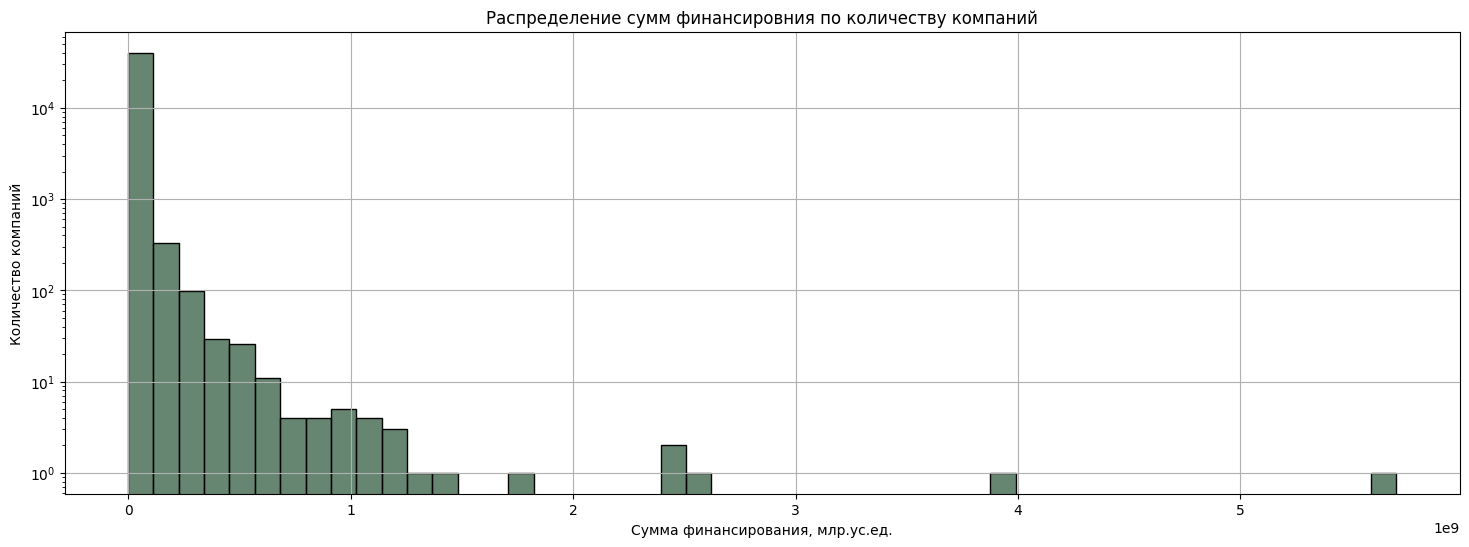

In [64]:
plt.figure(figsize = (18, 6))
sns.histplot(data = df_companies_filtered, 
             x = "funding_total", 
             bins = 50,
             color = "#335e41"
             ) 
plt.title('Распределение сумм финансировния по количеству компаний')
plt.ylabel('Количество компаний')
plt.xlabel('Сумма финансирования, млр.ус.ед.')
plt.yscale('log')  # Используем логарифмическую шкалу по Y для лучшей визуализации
plt.grid()
plt.show()

Судя по гистограмме распределения сумм финансирования видно, что большинство компаний имеют нулевое значение этого показателя.  
Построим boxplot-график, посмотрим на выбросы в данных

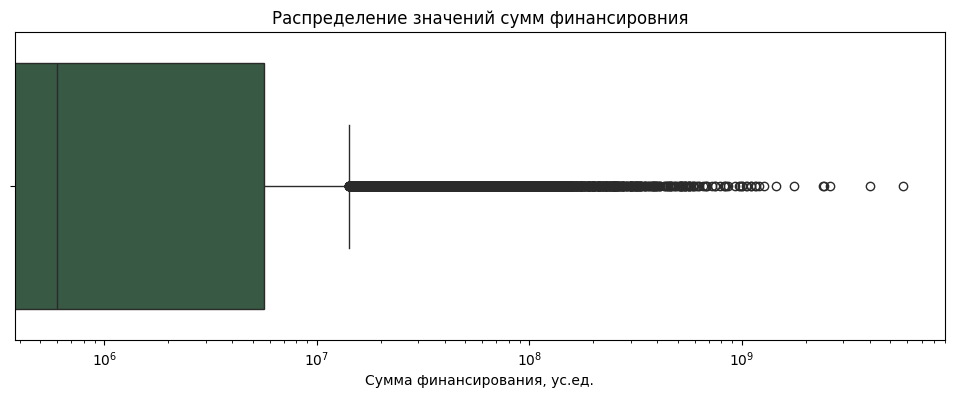

In [65]:
plt.figure(figsize=(12, 4))
sns.boxplot(data = df_companies_filtered, 
            x = "funding_total", 
            color = "#335e41",
            )   
# добавляем заголовок и метки оси
plt.title('Распределение значений сумм финансировния')
plt.xlabel('Сумма финансирования, ус.ед.')
plt.xscale('log')  # Используем логарифмическую шкалу по X для лучшей визуализации
plt.show()

На boxplot-графике видим выбросы данных вплоть до более милиарда, что сильно искажает данные. Медианное значение смещено влево, что говорит о сильном разбросе данных.  
Для более детального изучения значений столбца "funding_total" применим метод .describe()

In [66]:
df_companies_filtered['funding_total'].describe()

count        40747.000
mean      10135609.637
std       56464359.977
min              0.000
25%              0.000
50%         600000.000
75%        5650650.000
max     5700000000.000
Name: funding_total, dtype: float64

Интерпретируем результаты метода .describe():  
- **count** (Количество значений (без учета пропусков в данных)) — 40747. В данном случае, можно принять, как количество компаний, участвующих в анализе;
- **mean** (Среднее значение) — 10 135 609 (примерно 10 млн. усл.ед.); 
- **std** (Стандартное отклонение) — 56 464 359. Высокое стандартное отклонение указывает на сильный разброс значений в наборе данных относительно среднего значения.
- **min** (Минимальное значение) — 0. В данном случае, значение не является ошибкой, т.к. существуют компании, которые не получили финансирование;
- **25%** (Первый квартиль) — 0. Можно утверждать, что четверть компаний не получили финансирование;
- **50%** (Медиана) — 600 000 (600 тысяч  усл.ед.). Можно утверждать, что половина компаний получила финансирование меньше медианного значения, а другая половина - больше;
- **75%** (Третий квартиль) — 5 650 650 (5.65 млн. усл.ед.). Можно утверждать, что 3 четверти компаний получили сумму менее или равную этому значению;
- **max** (Максимальное значение) — 5 700 000 000 (5.7 млрд. усл.ед.). Похоже на ошибку, слишком большое значение.<br />
<br />
По результатам анализа данных столбца `funding_total` можно сказать о разнородности значений, обычные способы нахождения типичных значений на мой взгляд применимы при условии фильтрации данных от выбросов. 


### 3.3. Куплены забесплатно?

Исследуем компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования. 
<br /> 

Для этого нам необходимо объединить две таблицы: `acquisition` с информацией о покупках одними компаниями других компаний и `df_companies_filtered` с информацией о компаниях, у которых указаны значения "funding_rounds" или "investment_rounds" больше нуля, или те, у которых в колонке "status" указано "acquired" (эту таблицу мы сформировали в начале исследовательского анализа объединённых таблиц). Метод объединения выберем "left", чтобы сохранить все компании из `df_companies_filtered`.

In [67]:
# объединяем датафреймы в один
df_merged_sold = pd.merge(df_companies_filtered, 
                               df_acquisition,
                               left_on='company_id',  
                               right_on='acquired_company_id',  
                               how='left'
)

Применим фильтрацию данных, что бы получить датасет с нужной нам информацией.

In [68]:
sold_zero_or_dollar = df_merged_sold[
    (df_merged_sold['status'] == 'acquired') &  # условие продажи компании
    (df_merged_sold['funding_total'] > 0) &  # условие что у компании был ненулевой общий объём финансирования
    (df_merged_sold['price_amount'] == 0) |  # условие что сумма покупки равна 0
    (df_merged_sold['price_amount'] == 1)  # условие что сумма покупки равна 1
]

In [69]:
# проверяем результат
sold_zero_or_dollar

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
25,10054.000,Jumptap,mobile,acquired,2005-01-01,NaT,jumptap.com,jumptap,USA,0.000,7.000,121500000.000,3.000,9288.000,23283.000,10054.000,cash_and_stock,0.000,2013-08-13
63,101312.000,SideTour,web,acquired,2011-06-01,NaT,sidetour.com,sidetour,USA,0.000,3.000,4000000.000,2.000,9653.000,11391.000,101312.000,NaN,0.000,2013-09-18
66,101340.000,ChoicePass,enterprise,acquired,2011-07-01,NaT,choicepass.com,choicepass,USA,0.000,1.000,250000.000,1.000,7272.000,1972.000,101340.000,NaN,0.000,2012-06-18
67,10137.000,Producteev,software,acquired,2008-07-08,NaT,producteev.com,producteev,USA,0.000,3.000,1310000.000,2.000,8254.000,757.000,10137.000,cash_and_stock,0.000,2012-11-05
68,10139.000,TradeCard,enterprise,acquired,1999-01-01,NaT,tradecard.com,TradeCard,USA,0.000,2.000,44925000.000,1.000,9326.000,44008.000,10139.000,NaN,0.000,2013-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40834,99.000,Amie Street,web,acquired,2011-07-04,NaT,amiestreet.com,amiestreet_logs,USA,0.000,2.000,3900000.000,0.000,7024.000,317.000,99.000,NaN,0.000,2010-09-22
40836,9905.000,UBmatrix,software,acquired,2005-01-01,NaT,ubmatrix.com,NaN,USA,0.000,2.000,5172350.000,0.000,3381.000,41119.000,9905.000,NaN,0.000,2010-06-24
40840,992.000,wunderloop,advertising,acquired,1999-01-01,NaT,wunderloop.com,NaN,USA,0.000,1.000,10000000.000,1.000,9916.000,19182.000,992.000,NaN,0.000,2010-07-02
40854,997.000,Zimbra,enterprise,acquired,2003-01-01,NaT,zimbra.com,zimbra,USA,0.000,1.000,14500000.000,3.000,9121.000,415.000,997.000,NaN,0.000,2013-07-15


In [70]:
sold_zero_or_dollar['company_id'].nunique()

1596

Применим метод .describe() ко всему получившемуся датафрейму, что бы более детально узнать о компаниях из нашей выборки.

In [71]:
sold_zero_or_dollar.describe()

,company_id,founded_at,closed_at,investment_rounds,funding_rounds,funding_total,milestones,id,acquiring_company_id,acquired_company_id,price_amount,acquired_at
count,1621.000,1286,13,1621.000,1621.000,1621.000,1621.000,1621.000,1621.000,1621.000,1621.000,1617
mean,40044.125,2004-05-18 06:18:28.553654656,2010-05-12 16:36:55.384615424,0.008,1.887,18119366.086,1.455,6310.592,46482.199,40044.125,0.002,2011-03-02 20:34:17.142857216
min,9.000,1968-01-01 00:00:00,2001-02-01 00:00:00,0.000,0.000,0.000,0.000,14.000,5.000,9.000,0.000,1997-06-01 00:00:00
25%,10527.000,2001-01-01 00:00:00,2009-01-09 00:00:00,0.000,1.000,2000000.000,0.000,3913.000,2721.000,10527.000,0.000,2010-01-19 00:00:00
50%,27969.000,2005-06-01 00:00:00,2011-12-01 00:00:00,0.000,1.000,6000000.000,1.000,6802.000,18345.000,27969.000,0.000,2011-06-23 00:00:00
75%,49872.000,2008-01-28 12:00:00,2012-09-18 00:00:00,0.000,2.000,15500000.000,2.000,8856.000,52885.000,49872.000,0.000,2012-09-24 00:00:00
max,283073.000,2013-04-01 00:00:00,2013-09-17 00:00:00,3.000,12.000,5700000000.000,6.000,10513.000,284510.000,283073.000,1.000,2013-12-10 00:00:00
std,45594.428,NaN,NaN,0.119,1.245,144371275.916,1.227,2981.510,68849.541,45594.428,0.043,NaN


In [72]:
# посмотрим на распределение компаний в разрезе их стоимости покупки
sold_groupby = (sold_zero_or_dollar.groupby("price_amount")["company_id"]
                   .nunique()
                   .reset_index(name='nunique'))
# добавляем столбец с процентами
sold_groupby['percent'] = (sold_groupby['nunique'] / sold_groupby['nunique'].sum() * 100).round(2)
# выводим результат
display(sold_groupby)

,price_amount,nunique,percent
0,0.000,1593,99.810
1,1.000,3,0.190


После исследования компаний которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования, можно сказать следующее:
- всего таких компаний - 1596 (99.81% были куплены за 0 долларов, остальные 0.19% за 1 доллар;
- самый ранний год инвестирования в этих компаниях - 1968, самый поздний - 2013;
- закрытия компаний происходили в промежутке от 2001 до 2013 года;
- для подавляющего большинства компаний, число инвестиционных раундов - 0;
- медианное значение раундов финансирования - 1;
- минимальная сумма финансирования этих компаний - 0 усл.ед., максимальная - 5 700 000 000 (что вероятно является ошибкой);
- вехи финансирования распределены между значениями 0 и 6, с медианным значением - 1;
- сделки проходили между 1997 и 2013 годами.

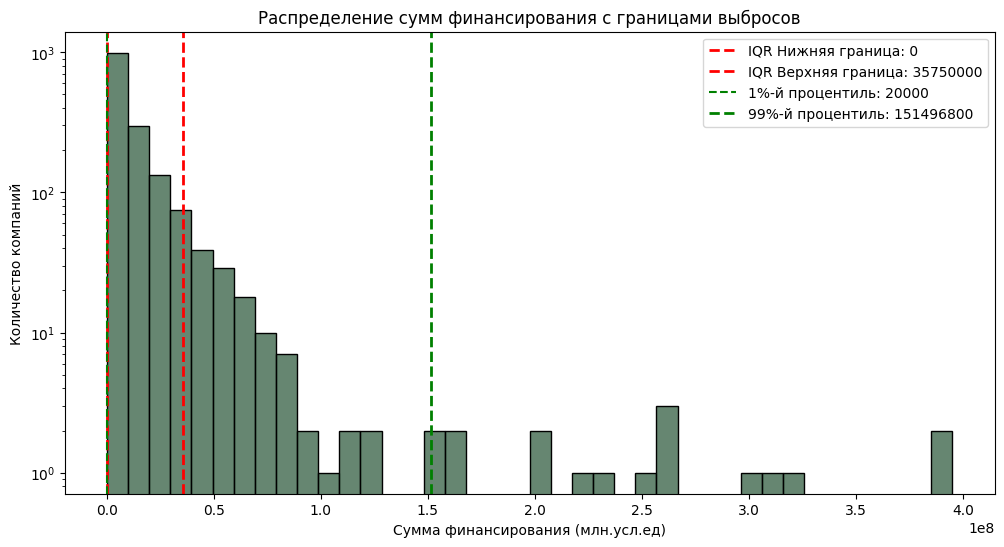

In [101]:
# расчет границ IQR
Q1 = sold_zero_or_dollar['funding_total'].quantile(0.25) # расчет первого квартиля (25-й процентиль)
Q3 = sold_zero_or_dollar['funding_total'].quantile(0.75) # расчет третьего квартиля (75-й процентиль)
IQR = Q3 - Q1 # расчет межквартильного размаха
lower_bound_iqr = max(0, Q1 - 1.5 * IQR) # расчет нижней границы для выбросов (граница не будет отрицательной)
upper_bound_iqr = Q3 + 1.5 * IQR # расчет верхней границы для выбросов

# расчет границ по процентилям
lower_bound_percentile = sold_zero_or_dollar['funding_total'].quantile(0.01) # расчет 1-го процентиля
upper_bound_percentile = sold_zero_or_dollar['funding_total'].quantile(0.99) # расчет 99-го процентиля

# Гистограмма с границами
plt.figure(figsize=(12, 6))
sns.histplot(data = sold_zero_or_dollar[sold_zero_or_dollar['funding_total'] < 5000000000], # для лучшей читаемости графика, отфильтровали значения меньше 5 млр. усл.ед.
             x = "funding_total", 
             bins = 40,
             color = "#335e41"
             ) 
plt.axvline(lower_bound_iqr, color='red', linestyle='--', linewidth=2, label=f'IQR Нижняя граница: {lower_bound_iqr:.0f}')
plt.axvline(upper_bound_iqr, color='red', linestyle='--', linewidth=2, label=f'IQR Верхняя граница: {upper_bound_iqr:.0f}')
plt.axvline(lower_bound_percentile, color='green', linestyle='--', label=f'1%-й процентиль: {lower_bound_percentile:.0f}')
plt.axvline(upper_bound_percentile, color='green', linestyle='--', linewidth=2, label=f'99%-й процентиль: {upper_bound_percentile:.0f}')
plt.title('Распределение сумм финансирования с границами выбросов')
plt.xlabel('Сумма финансирования (млн.усл.ед)')
plt.ylabel('Количество компаний')
plt.yscale('log')  # Логарифмическая шкала для лучшей визуализации
plt.legend()
plt.show()


---
В соответствии с графиком можно сказать следующее:

**Границы выбросов методом IQR:**
- нижняя граница - 0 (соответствует 0%-му процентилю);
- верхняя граница - 35 750 000.

**Замена границ на процентили:**
- нижняя граница: 20 000 (соответствует 1%-му процентилю)
- верхняя граница: 151 496 800 (99%-й процентиль)<br />
Замена на процентили может быть обоснована, если цель — сохранить больше данных и избежать потери редких наблюдений.

Как показывают расчеты, процентили лучше отражают реальное распределение значений (особенно при наших сильно скошеных данных).
Значения по процентилям менее чувствительны к экстремальным выбросам, чем границы IQR.
Замена на 1%-й и 99%-й процентили позволяет сохранить большую часть данных, исключив только самые экстремальные значения.


### 3.4. Цены стартапов по категориям


In [113]:
df_hight_price = (
    df_merged_sold.groupby('category_code')['price_amount']
        .agg(['median', 'count'])
        .query('count >= 5') # фильтруем данные, что бы в выборуку попали компании, количество которых больше 5
        .sort_values(by = 'median', ascending=False)
)
df_hight_price.head(5)

,median,count
category_code,,
manufacturing,72000000.000,29
real_estate,50000000.000,7
automotive,43000000.000,5
biotech,13200000.000,454
hospitality,12500000.000,11


В результате оценки категорий стартапов с типично высокими ценами покупки получили Топ-5 (данный топ достаточно компактен для анализа, но в то же время позволяет выделить ключевые категории) компаний.  
В качестве метрики выбрали - медиану, поскльку она лучше характеризует цену (например среднее значение более подвержено искажениям из-за неоднородности наших данных).  
Произвели фильтрацию данных (в выборке только категории с количеством компаний 5 и более), что бы наш топ был более обстоятельный. 

In [118]:
df_std_price = (
    df_merged_sold.groupby('category_code')['price_amount']
        .agg(['std', 'count'])
        .query('count >= 5') # фильтруем данные, что бы в выборуку попали компании, количество которых больше 5
        .sort_values(by = 'std', ascending=False)
)
df_std_price.head(5)

,std,count
category_code,,
enterprise,128088235060.169,412
public_relations,4059244205.048,219
real_estate,2505122913.057,7
automotive,2297757559.013,5
biotech,1540373521.411,454


Если смотреть на Топ-5 категорий стартапов по значительным разбросам цен, можно отметить довольно большие значения стандартного отклонения, что говорит о высокой волатильности цен в этих категориях, что в свою очередь, при правильном подходе, может принести инвесторам дополнительую прибыль. 



### 3.5. Сколько раундов продержится стартап перед покупкой


In [123]:
# фильтруем датафрейм, что бы были только компании, которые получили финансирование
df_funded_companies = df_companies_filtered[df_companies_filtered['funding_rounds'] > 0]

In [128]:
# группируем данные по статусу и расчитываем основные метрики для столбца "funding_rounds"
rounds_by_status = df_funded_companies.groupby('status')['funding_rounds'].agg(
    count='count',  # Количество компаний в каждой группе
    mean='mean',    # Среднее количество раундов
    median='median', # Медиана количества раундов
    min='min',      # Минимальное количество раундов
    max='max'       # Максимальное количество раундов
).sort_values(by = 'mean', ascending=False).reset_index()

rounds_by_status

,status,count,mean,median,min,max
0,ipo,490,2.527,2.000,1.000,13.000
1,acquired,2593,1.897,1.000,1.000,12.000
2,operating,26535,1.642,1.000,1.000,15.000
3,closed,2089,1.383,1.000,1.000,8.000


После анализа значений столбца `funding_rounds` можно сделать следующие выводы: 
- **ipo:** Среднее количество раундов — 2.527, медиана — 2. Самый высокий показатель среднего значения и медианы показывает, что компании, вышедшие на ipo, как правило проходят более длительный и сложный путь с несколькими этапами привлечения капитала, что делает их более подготовленными к публичному размещению.
- **acquired:** Среднее количество раундов — 1.897, медиана — 1. Эти показатели говорят о том, что приобретенные компании чаще имели хотя бы один раунд финансирования, что указывает на более зрелый этап развития. Многие из них могли быть куплены на стадии роста, что делает их более привлекательными для инвесторов.
- **operating:** Среднее количество раундов — 1.642, медиана — 1. Работающие компании находятся между закрывшимися и приобретенными компаниями, что указывает на их потенциал для дальнейшего роста.
- **closed:** Среднее количество раундов — 1.383, медиана — 1. Закрывшиеся компании имеют самое низкое среднее количество раундов, что указывает на то, что они, как правило, не смогли привлечь достаточное количество инвестиций для устойчивого роста.

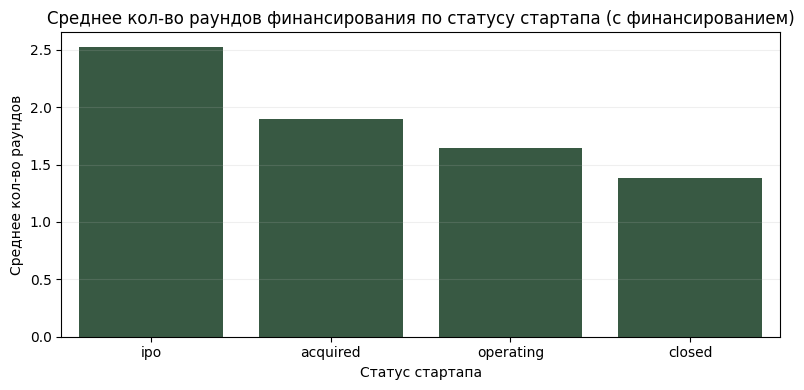

In [138]:
# Создаем график
plt.figure(figsize=(8, 4))
sns.barplot(
    data=rounds_by_status,
    x='status',  
    y='mean',    
    color='#335e41',
)
plt.title('Среднее кол-во раундов финансирования по статусу стартапа (с финансированием)', fontsize=12)
plt.xlabel('Статус стартапа', fontsize=10)
plt.ylabel('Среднее кол-во раундов', fontsize=10)
plt.tight_layout()  # Автоматическая настройка расположения элементов
plt.grid(axis='y', alpha=0.2)
plt.show()

График показывает что **компании, вышедшие на ipo**, имеют наибольшее среднее количество раундов (2.527), что почти в два раза превышает количесто раундов у закрытых компаний — 1.383. Данный показатель можно объяснить тем, что такие компании, как правило проходят более длительный путь с несколькими этапами привлечения капитала, таким компаниям требуется больше инвестиций для выхода на биржу.
<br />

**Приобретенные компании** имеют второй по величине показатель среднего количества раундов (1.897), такие компании часто становятся целью поглощения после нескольких успешных раундов, плюс могут быть куплены до выхода на ipo для быстрой монетизации.
<br />

Далее следуют **работающие компании** с показателем - 1.642, эти компании могут использовать реинвестирование прибыли вместо привлечения инвестиций, что отражается на среднем значении.
<br />

На последнем месте по показателю среднего количества раундов (1.383) находятся **закрытые компании**. Возможно, как раз недостаток финансирования мог стать одной из причин закрытия.

<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">
    
## Шаг 4. Итоговый вывод и рекомендации <a id='final_conclusion'></a>

Целью нашего исследования был анализ исторических данных для разработки бизнес-модели инвестирования в стартапы, включая покупку, развитие и перепродажу.
<br />

В рамках работы, первоначально было проведено знакомство с данными, после которого мы:
- привели названия столбцов датафрейма `company_and_rounds` к формату "snake_case", так же переименовали столбец "company id" в "company_id_dupl";
- поменяли тип данных (которые хранят значения даты и времени) для столбцов датафреймов `company_and_rounds`, `acquisition` и `education` c "object" на "datetime64[ns]";
- оценили полноту данных, вывели количество пропусков в датасетах. В части работы с пропусками, оставили их без изменений, т.к. удаление строк с пропусками привело бы к большой потере данных, так же у нас не было столбцов на основе которых мы могли бы эти пропуски заполнить. Учитывая размер датасета `company_and_rounds` даже с учетом пропусков, у нас оставалась довольно большая выборка.
<br />

Далее мы приступили к предобработке и предварительному исследованию данных, в результате этой работы сделали следующие выводы:
* в части типичного размера собранных в рамках одного раунда средств:
    + 2005 год является лидером по типичному размеру собранных в рамках одного раунда средств (5 500 000.0 усл.ед. и 1633 раундов финансирования);
    + в целом, период с 2004 по 2006 годы включительно, был самым щедрым по величине стредств выделяемых в рамках одного раунда финансирования;
    + после 2005 года наблюдается нисходящая тенденция по величине стредств выделяемых в рамках одного раунда финансирования, однако количество раундов финансирования наоборот растет.
    + если рассматривать отдельно 2013 год, то можно сказать об увеличении размера средств выделяемых в рамках одного раунда финансирования к концу года, по количеству раундов финансирования заметной тенденции не наблюдалось.
* в части зависимости полноты сведений о сотрудниках от размера компаний:
    + самый большой процент сотрудников без информации об образовании наблюдается в компаниях с 1-м сотрудником - 59.3% (возможно это связано с гораздо большим количеством этих компаний по сравнению с другими). В компаниях с 2-мя и 3-мя сотрудниками одни из самых низких процентов - 22.7% и 22.8% соответсвтенно, самый низкий процент наблюдаетя в компаниях с 26+ сотрудниками - 19.1% (однако, учитывая, что в наших данных таких компаний 19 или всего 0.1% от общего количества, результат по этой категории мог быть не точным).
* в части использования столбца с именем `network_username` для объединения данных:
    + при помощи диаграммы Венна мы наглядно увидели, что объединение двух датафреймов `df_company_and_rounds` и `df_people` по столбцу `network_username` не является оптимальным решением (например при способе объединения "inner" мы потеряем значительную часть информации из обоих таблиц, при способе объединения "left" получим много значений NaN. Из положительных моментов данного объединения наверное можно отметить только появление в таблице `df_company_and_rounds` информации о сотрудниках, что может помоч в некоторых вариантах агрегации данных).
* в части проблемного датасета `df_company_and_rounds` и причины возникновения пропусков:
    + были созданы два датасета `df_companies` и `df_rounds`;  
    + датасеты не содержат дубликатов и пустых строк, связность данных осуществляется через столбец `company_id`;
    + данные позволяют отобрать компании по параметрам и рассчитать показатели из расчёта на одну компанию без промежуточных агрегаций.
<br />

После предобработки и предварительного исследования приступили к исследовательскому анализу объединённых таблиц:
* подготовили отфильтрованный датафрейм `df_companies_filtered`, в котором представлены компании, у которых указаны значения `funding_rounds` или `investment_rounds` больше нуля, или те, у которых в колонке `status` указано `acquired`.
* интерпретировали результаты метода .describe() для столбца `funding_total` (по результатам анализа можно сказать о разнородности значений, обычные способы нахождения типичных значений на мой взгляд применимы при условии фильтрации данных от выбросов.) **более подробный вывод находится в п.3.2 данного исследования*
* исследовали компании, которые были проданы за ноль или за один доллар, сделали следующие выводы:
    + всего таких компаний - 1596 (99.81% были куплены за 0 долларов, остальные 0.19% за 1 доллар;
    + самый ранний год инвестирования в этих компаниях - 1968, самый поздний - 2013;
    + закрытия компаний происходили в промежутке от 2001 до 2013 года;
    + для подавляющего большинства компаний, число инвестиционных раундов - 0;
    + медианное значение раундов финансирования - 1;
    + минимальная сумма финансирования этих компаний - 0 усл.ед., максимальная - 5 700 000 000 (что вероятно является ошибкой);
    + вехи финансирования распределены между значениями 0 и 6, с медианным значением - 1;
    + сделки проходили между 1997 и 2013 годами
* рассчитали аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total`, выяснили, что процентили лучше отражают реальное распределение значений (особенно при наших сильно скошеных данных). Значения по процентилям менее чувствительны к экстремальным выбросам, чем границы IQR. Замена на 1%-й и 99%-й процентили позволяет сохранить большую часть данных, исключив только самые экстремальные значения.
* получили Топ-5 компаний с типично высокими ценами покупки. В качестве метрики выбрали - медиану, произвели фильтрацию данных (в выборке только категории с количеством компаний 5 и более), что бы наш топ был более обстоятельный.
* получили Топ-5 категорий стартапов по значительным разбросам цен, отметили довольно большие значения стандартного отклонения, что говорит о высокой волатильности цен в этих категориях, что в свою очередь, при правильном подходе, может принести инвесторам дополнительую прибыль.
* исследовали тему количества раундов стартапов перед покупкой, графически отобразили, сколько в среднем раундов финансирования проходило для стартапов из каждой групп.
<br />

В целом можно отметить корреляцию между количеством раундов финансирования и успешностью компании. Наше исследование в разрезе количества раундов финансирования стартапов перед покупкой показывает, что компании с меньшим чем 1.38 раундами в среднем не выживают, 1.9 раунда — это уровень, при котором стартап становится привлекательным для поглощения, а 2.5 и более раундов необходимы для выхода на биржу.  
<br />
Инвесторам стоит обратить внимание на компании после 2-го раунда — это наиболее перспективные кандидаты на IPO, в качестве категории области деятельности компании можно выделить "manufacturing" и "hospitality", к остальным категориям "real_estate", "automotive" и "biotech" нужно относиться с осторожностью в виду их высокой волатильности.<br />
В качестве рекоммендации для исследования я бы добавил расчеты метрик в зависимости от региона компании, это возможно дало бы нам более детальную информацию. 	  





















